# Description
```
Name      : broke_captcha_code
Problem   : Classification
Algorithm : Neural Network
Formula   : Weightes-Sum
Action    : relu
Loss      : categorical_crossentropy
Optimizer : adam 
Train     : Supervised
Input     : Feature and label
Output    : 
Dataset   : Unstructured : captcha
Tag       : 
```

# General

### Import

In [41]:
import glob
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from keras import optimizers
from keras import losses
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras import models, layers
from keras.models import load_model

### Variable

In [9]:
root_dir = '/Volumes/data/documents/ai_document'

# Captcha

### Display

In [10]:
img = cv.imread(f"{root_dir}/pic/captcha.png")
print(img.shape)
cv.imshow('image', img)
cv.waitKey(1)
cv.destroyAllWindows()

(352, 1460, 3)


### Convert to gray

In [11]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
print(gray.shape)
cv.imshow('gray', gray)
cv.waitKey(1)
cv.destroyAllWindows()

(352, 1460)


### Convert to binary

In [12]:
T, binary = cv.threshold(gray, 100, 255, cv.THRESH_BINARY_INV)
print(binary.shape)
cv.imshow('binary', binary)
cv.waitKey(1)
cv.destroyAllWindows()

(352, 1460)


### Contour

In [13]:
cnets, hierarchy = cv.findContours(binary, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
print(f"{len(cnets)} contours")
for cent in cnets : print(cent.shape)
cv.drawContours(img, cnets, -1, (0,255,0), 1) 
cv.imshow('contour', img)
cv.waitKey(1) 
cv.destroyAllWindows()

4 contours
(68, 1, 2)
(74, 1, 2)
(66, 1, 2)
(90, 1, 2)


### Box

In [14]:
for cent in cnets : 
    x, y, w, h = cv.boundingRect(cent)
    cv.rectangle(img, (x-5, y-5), (x+w+5, y+h+5), (0,0,255), 2)
cv.imshow('box', img)
cv.waitKey(1) 
cv.destroyAllWindows()

# Dataset

### Data

In [15]:
data = []
for address in glob.glob(f"{root_dir}/dataset/captcha/**/*.png"):
    img = cv.imread(address)
    data.append(img)

### Labels

In [16]:
labels = []
for address in glob.glob(f"{root_dir}/dataset/captcha/**/*.png"):
    label = address.split('/')[-2].split('.')[0]
    labels.append(label)

# Preprocessing

### General

In [17]:
x = []
for img in data:
    #---Convert to gray
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    ##---Resize
    img = cv.resize(img, (32, 32))
    #---Normalization
    img = img/255.0
    #---Flatten
    img = img.flatten()
    #---Add
    x.append(img)
#---Convert
x = np.array(x)

### Separate tarin and test

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, labels, test_size=0.2)
print(x_train.shape)
print(x_test.shape)
print(len(y_train))
print(len(y_test))

(1609, 1024)
(403, 1024)
1609
403


### Convert label to encoding

In [19]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_train = to_categorical(y_train)
y_test = le.fit_transform(y_test)
y_test = to_categorical(y_test)
print(y_train[0])

[0. 1. 0. 0. 0. 0. 0. 0. 0.]


# Model

In [ ]:
opt = optimizers.Adam()
mdl = models.Sequential()
mdl.add(layers.Dense(64, activation="relu"))
mdl.add(layers.Dense(32, activation="relu"))
mdl.add(layers.Dense(9, activation="softmax")) 
mdl.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
mdl.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train

In [32]:
EPOCHS = 5
BATCH_SIZE = 16
h = mdl.fit(x_train, y_train ,batch_size=BATCH_SIZE, epochs=EPOCHS, validation_data=(x_test, y_test))

Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - accuracy: 0.9970 - loss: 0.0264 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - accuracy: 0.9974 - loss: 0.0247 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - accuracy: 0.9977 - loss: 0.0173 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 887us/step - accuracy: 0.9989 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - accuracy: 0.9972 - loss: 0.0140 - val_accuracy: 0.9429 - val_loss: 0.1473


### Save

In [22]:
mdl.save(f"{root_dir}/dataset/captcha.h5")

# Evaluation

### Loss and Accuracy

In [33]:
loss, accuracy = mdl.evaluate(x_test, y_test)
print("Loss: {:.2f} | Accuracy: {:.2f}".format(loss, accuracy))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9257 - loss: 0.1736
Loss: 0.15 | Accuracy: 0.94


### History

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


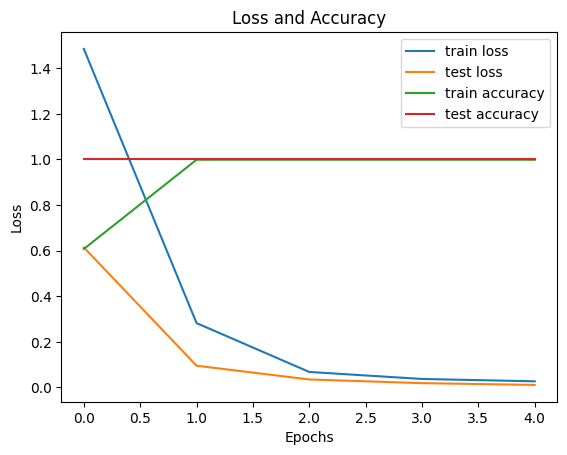

In [24]:
print(h.history.keys())
plt.plot(np.arange(EPOCHS), h.history['loss'], label='train loss')
plt.plot(np.arange(EPOCHS), h.history['val_loss'], label='test loss')
plt.plot(np.arange(EPOCHS), h.history['accuracy'], label='train accuracy')
plt.plot(np.arange(EPOCHS), h.history['val_accuracy'], label='test accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss and Accuracy')
plt.style.use('ggplot')
plt.show()

# Test

In [25]:
img = cv.imread(f"{root_dir}/pic/captcha.png")
mdl = load_model(f"{root_dir}/dataset/captcha.h5")
for cent in cnets : 
    x, y, w, h = cv.boundingRect(cent)
    item = img[y-5:y+5+h, x-5:x+5+w]
    #---Preprocessing  
    item = cv.cvtColor(item, cv.COLOR_BGR2GRAY)
    item = cv.resize(item, (32, 32))
    item = item.flatten()
    item = item/255.0
    item = np.array([item])
    out = mdl.predict(item)[0]
    max_index = np.argmax(out)+1
    cv.putText(img, str(max_index), (x-5, y-5), cv.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 2)
cv.imshow('test', img)
cv.waitKey(1) 
cv.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
